In [ ]:
# That is not raw EEG time-series but rather precomputed features.
# Reason: Bandpass filtering failed (input too short).Spectrogram failed (nperseg=128 > len=16).
# inOrder treat each row as a feature vector.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ========== Step 1: Load BEED ==========
data_path = "/kaggle/input/beed-dataset/BEED_Data.csv"
df = pd.read_csv(data_path)
print(df.head())

X = df.drop(columns=["y"]).values
y_raw = df["y"].values

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y_raw)

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=16)

# ========== Step 2: Simple MLP Classifier ==========
class EEGMLP(nn.Module):
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )
    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EEGMLP(in_features=X.shape[1], num_classes=len(np.unique(y))).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# ========== Step 3: Train ==========
for epoch in range(10):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

# ========== Step 4: Evaluate ==========
model.eval()
preds, trues = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = model(xb)
        _, pred = torch.max(out, 1)
        preds.extend(pred.cpu().numpy())
        trues.extend(yb.numpy())

acc = accuracy_score(trues, preds)
print("Test Accuracy:", acc)
print(classification_report(trues, preds, target_names=[str(c) for c in le.classes_]))


# ========== Step 5: LLM Integration ==========
# Instead of just outputting "class=0", let’s map to natural-language explanations
emotion_map = {
    0: "Calm state detected — participant shows stable brain activity.",
    1: "Stress indicators present — elevated brain features linked to anxiety.",
    2: "Excited emotional state — strong activations across EEG bands.",
    # extend mapping based on BEED labels
}

def explain_prediction(sample_idx):
    x = X_test[sample_idx].unsqueeze(0).to(device)
    out = model(x)
    pred = torch.argmax(out, dim=1).item()
    emotion = le.inverse_transform([pred])[0]
    explanation = emotion_map.get(pred, f"Emotion {emotion} detected.")
    return emotion, explanation

# Example
emo, exp = explain_prediction(0)
print("Predicted Emotion:", emo)
print("Explanation:", exp)


    X1   X2   X3   X4   X5   X6  X7  X8  X9  X10  X11  X12  X13  X14  X15  \
0    4    7   18   25   28   27  20  10 -10  -18  -20  -16   13   32   12   
1   87  114  120  106   76   54  28   5 -19  -49  -85 -102 -100  -89  -61   
2 -131 -133 -140 -131 -123 -108 -58 -51 -70  -77  -76  -76  -73  -57  -40   
3   68  104   73   34  -12  -26 -38 -36 -67  -88  -25   31   18   -4    6   
4  -67  -90  -97  -94  -86  -71 -43 -11  23   46   58   50   39   19   -9   

   X16  y  
0   10  0  
1  -21  0  
2  -14  0  
3  -29  0  
4  -41  0  
Epoch 1, Loss: 0.9263
Epoch 2, Loss: 0.6236
Epoch 3, Loss: 0.5286
Epoch 4, Loss: 0.4735
Epoch 5, Loss: 0.4323
Epoch 6, Loss: 0.3914
Epoch 7, Loss: 0.3827
Epoch 8, Loss: 0.3634
Epoch 9, Loss: 0.3526
Epoch 10, Loss: 0.3439
Test Accuracy: 0.888125
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       425
           1       0.91      0.92      0.92       379
           2       0.80      0.87      0.84       397
   

In [ ]:
# CNN ----> LSTM hybrid

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Config
DATA_PATH = "/kaggle/input/beed-dataset/BEED_Data.csv"
LABEL_COL = "y"
BATCH_SIZE = 32
EPOCHS = 30
LR = 1e-3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Data
df = pd.read_csv(DATA_PATH)
X = df.drop(columns=[LABEL_COL]).values.astype(np.float32)
y_raw = df[LABEL_COL].values
le = LabelEncoder()
y = le.fit_transform(y_raw)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for CNN+LSTM: (batch, seq_len, features=1)
X_train = X_train[..., np.newaxis]  # (N, seq_len, 1)
X_test = X_test[..., np.newaxis]

# Torch datasets
train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                         torch.tensor(y_train, dtype=torch.long))
test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                        torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Model: 1D-CNN + LSTM

class CNN_LSTM(nn.Module):
    def __init__(self, seq_len, num_classes, hidden_dim=64, lstm_layers=1):
        super(CNN_LSTM, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(32)
        self.pool = nn.MaxPool1d(2)

        # After conv: (batch, 32, seq_len/2)
        lstm_input_dim = 32
        self.lstm = nn.LSTM(input_size=lstm_input_dim, hidden_size=hidden_dim,
                            num_layers=lstm_layers, batch_first=True, bidirectional=True)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        # x: (batch, seq_len, 1) → transpose to (batch, channels=1, seq_len)
        x = x.transpose(1, 2)
        x = self.conv1(x)   # (batch, 32, seq_len)
        x = torch.relu(self.bn1(x))
        x = self.pool(x)    # (batch, 32, seq_len/2)

        # Prepare for LSTM: (batch, seq_len/2, 32)
        x = x.transpose(1, 2)
        out, _ = self.lstm(x)
        out = out[:, -1, :]   # take last hidden state
        logits = self.fc(out)
        return logits

model = CNN_LSTM(seq_len=X_train.shape[1], num_classes=len(le.classes_)).to(device)

# Train
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

for epoch in range(1, EPOCHS+1):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)

    print(f"Epoch {epoch}: Train Loss={total_loss/total:.4f}, Train Acc={correct/total:.4f}")

# Evaluate
model.eval()
preds, trues = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        preds.extend(logits.argmax(1).cpu().numpy())
        trues.extend(yb.cpu().numpy())

acc = accuracy_score(trues, preds)
print("Test Accuracy:", acc)
print("Classification Report:\n", classification_report(trues, preds, target_names=[str(c) for c in le.classes_]))
print("Confusion Matrix:\n", confusion_matrix(trues, preds))


Epoch 1: Train Loss=0.8864, Train Acc=0.5705
Epoch 2: Train Loss=0.7161, Train Acc=0.6494
Epoch 3: Train Loss=0.6848, Train Acc=0.6753
Epoch 4: Train Loss=0.6739, Train Acc=0.6830
Epoch 5: Train Loss=0.6377, Train Acc=0.6978
Epoch 6: Train Loss=0.5520, Train Acc=0.7541
Epoch 7: Train Loss=0.4799, Train Acc=0.7936
Epoch 8: Train Loss=0.4634, Train Acc=0.7963
Epoch 9: Train Loss=0.4373, Train Acc=0.8158
Epoch 10: Train Loss=0.4322, Train Acc=0.8184
Epoch 11: Train Loss=0.3998, Train Acc=0.8330
Epoch 12: Train Loss=0.3828, Train Acc=0.8419
Epoch 13: Train Loss=0.3692, Train Acc=0.8438
Epoch 14: Train Loss=0.3692, Train Acc=0.8559
Epoch 15: Train Loss=0.3388, Train Acc=0.8580
Epoch 16: Train Loss=0.3265, Train Acc=0.8664
Epoch 17: Train Loss=0.3143, Train Acc=0.8723
Epoch 18: Train Loss=0.3159, Train Acc=0.8680
Epoch 19: Train Loss=0.2922, Train Acc=0.8823
Epoch 20: Train Loss=0.2886, Train Acc=0.8808
Epoch 21: Train Loss=0.2717, Train Acc=0.8894
Epoch 22: Train Loss=0.2694, Train Acc=0.88

In [ ]:
# Class Imbalance Test

In [3]:
!pip install -q scikit-learn==1.5.2 imbalanced-learn==0.10.1


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 60.4 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.0/226.0 kB 13.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.


Classes: [0 1 2 3]
Counts: Counter({0: 2000, 1: 2000, 2: 2000, 3: 2000})

=== EXPERIMENT 0: Baseline MLP ===
Accuracy: 0.91875
Balanced Acc: 0.9187500000000001
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.97      0.94      0.96       400
           2       0.87      0.89      0.88       400
           3       0.84      0.85      0.84       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600

Confusion matrix:
 [[399   0   0   1]
 [  0 375   4  21]
 [  0   1 356  43]
 [  0   9  51 340]]

=== EXPERIMENT 1: Class-weighted loss ===
Accuracy: 0.905625
Balanced Acc: 0.905625
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       0.98      0.90      0.94       400
           2 

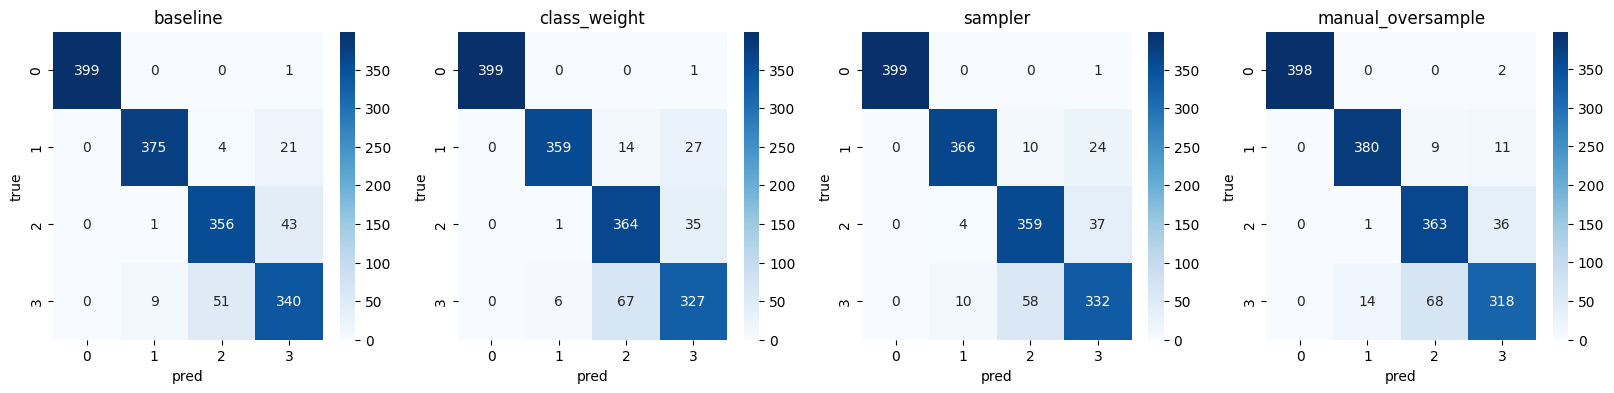

In [2]:
# =========================================
# EEG Class Imbalance Analysis + Mitigation
# Using PyTorch & scikit-learn ONLY
# =========================================

# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

# --- Config ---
DATA_PATH = "/kaggle/input/beed-dataset/BEED_Data.csv"  # Adjust path
LABEL_COL = "y"
RANDOM_SEED = 42
BATCH_SIZE = 64
EPOCHS = 20
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Load & preprocess ---
df = pd.read_csv(DATA_PATH)
X = df.drop(columns=[LABEL_COL]).values.astype(np.float32)
y_raw = df[LABEL_COL].values
le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Classes:", le.classes_)
print("Counts:", Counter(y))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# --- Helper function to evaluate predictions ---
def eval_preds(y_true, y_pred, label_encoder=le):
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Balanced Acc:", balanced_accuracy_score(y_true, y_pred))
    print("Classification report:\n", classification_report(
        y_true, y_pred, target_names=[str(c) for c in label_encoder.classes_]))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

# --- Simple MLP ---
class SimpleMLP(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_classes)
        )
    def forward(self, x):
        return self.net(x)

# --- Training function ---
def train_model(model, train_loader, val_X, val_y,
                epochs=EPOCHS, lr=LR, device=DEVICE, class_weights=None):
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=class_weights) if class_weights is not None else nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total = 0
        correct = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            opt.step()
            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    # Evaluate on test set
    model.eval()
    with torch.no_grad():
        Xv = torch.tensor(val_X, dtype=torch.float32).to(device)
        logits = model(Xv)
        preds = logits.argmax(dim=1).cpu().numpy()
    return preds, model

# =========================================
# Experiment 0: Baseline MLP (no imbalance handling)
# =========================================
print("\n=== EXPERIMENT 0: Baseline MLP ===")
train_dataset = TensorDataset(torch.tensor(X_train_s, dtype=torch.float32),
                              torch.tensor(y_train, dtype=torch.long))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

model0 = SimpleMLP(in_dim=X_train_s.shape[1], n_classes=len(np.unique(y)))
preds0, m0 = train_model(model0, train_loader, X_test_s, y_test)
eval_preds(y_test, preds0)

# =========================================
# Experiment 1: Class-weighted loss
# =========================================
print("\n=== EXPERIMENT 1: Class-weighted loss ===")
classes = np.unique(y_train)
class_weights_np = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
cw = torch.tensor(class_weights_np, dtype=torch.float32).to(DEVICE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
model1 = SimpleMLP(in_dim=X_train_s.shape[1], n_classes=len(np.unique(y)))
preds1, m1 = train_model(model1, train_loader, X_test_s, y_test, class_weights=cw)
eval_preds(y_test, preds1)

# =========================================
# Experiment 2: WeightedRandomSampler
# =========================================
print("\n=== EXPERIMENT 2: WeightedRandomSampler Oversampling ===")
counts = Counter(y_train)
sample_weights = np.array([1.0 / counts[label] for label in y_train])
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
train_loader_sampler = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)

model2 = SimpleMLP(in_dim=X_train_s.shape[1], n_classes=len(np.unique(y)))
preds2, m2 = train_model(model2, train_loader_sampler, X_test_s, y_test)
eval_preds(y_test, preds2)

# =========================================
# Experiment 3: Manual oversampling (like SMOTE-lite)
# =========================================
print("\n=== EXPERIMENT 3: Manual oversampling ===")
counts = Counter(y_train)
minority_class = min(counts, key=counts.get)
n_samples_needed = max(counts.values()) - counts[minority_class]

# Get minority class samples
X_min = X_train_s[y_train == minority_class]
y_min = y_train[y_train == minority_class]

# Resample with replacement
X_resampled, y_resampled = resample(X_min, y_min,
                                    replace=True,
                                    n_samples=n_samples_needed,
                                    random_state=RANDOM_SEED)

# Append to original training set
X_train_res = np.vstack([X_train_s, X_resampled])
y_train_res = np.hstack([y_train, y_resampled])

# Convert to DataLoader
train_dataset_res = TensorDataset(torch.tensor(X_train_res, dtype=torch.float32),
                                  torch.tensor(y_train_res, dtype=torch.long))
train_loader_res = DataLoader(train_dataset_res, batch_size=BATCH_SIZE, shuffle=True)

model3 = SimpleMLP(in_dim=X_train_res.shape[1], n_classes=len(np.unique(y)))
preds3, m3 = train_model(model3, train_loader_res, X_test_s, y_test)
eval_preds(y_test, preds3)

# =========================================
# Summary Table
# =========================================
summary = pd.DataFrame({
    "method": ["baseline", "class_weight", "sampler", "manual_oversample"],
    "accuracy": [accuracy_score(y_test, preds0),
                 accuracy_score(y_test, preds1),
                 accuracy_score(y_test, preds2),
                 accuracy_score(y_test, preds3)],
    "balanced_acc": [balanced_accuracy_score(y_test, preds0),
                     balanced_accuracy_score(y_test, preds1),
                     balanced_accuracy_score(y_test, preds2),
                     balanced_accuracy_score(y_test, preds3)]
})
print("\n=== Summary ===")
print(summary)

# Optional: Confusion matrices side-by-side
import seaborn as sns
fig, axes = plt.subplots(1,4, figsize=(20,4))
for ax, preds, title in zip(axes,
                            [preds0, preds1, preds2, preds3],
                            ["baseline","class_weight","sampler","manual_oversample"]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("pred")
    ax.set_ylabel("true")
plt.show()
